## toy acquisition function: $e^{-0.5\frac{(x/0.1-0.6)^2}{0.08^2}}$

In [1]:
def toy_acquisition(X):
    """
    X: (N, 1)
    return: (N,)
    """
    mu = 0.6
    sigma = 0.08
    return torch.exp(-0.5 * ((X.squeeze() - mu) / sigma) ** 2)

/data1/qcq4123155034/CBBO


/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data1/qcq4123155034/CBBO/cbbo/coverage_kernels.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_tensor = torch.tensor(bounds).T


------{l_i}: 1


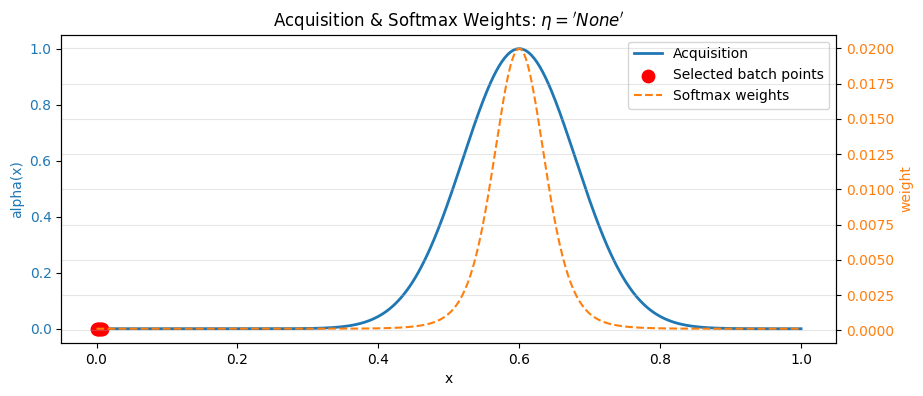

In [2]:
import sys
import os
import torch
import matplotlib.pyplot as plt

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 1.0]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l='None',
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 'None'$")
plt.grid(alpha=0.3)
plt.show()

/data1/qcq4123155034/CBBO
---------X: tensor([[0.0000],
        [0.0020],
        [0.0040],
        [0.0060],
        [0.0080],
        [0.0100],
        [0.0120],
        [0.0140],
        [0.0160],
        [0.0180],
        [0.0200],
        [0.0220],
        [0.0240],
        [0.0261],
        [0.0281],
        [0.0301],
        [0.0321],
        [0.0341],
        [0.0361],
        [0.0381],
        [0.0401],
        [0.0421],
        [0.0441],
        [0.0461],
        [0.0481],
        [0.0501],
        [0.0521],
        [0.0541],
        [0.0561],
        [0.0581],
        [0.0601],
        [0.0621],
        [0.0641],
        [0.0661],
        [0.0681],
        [0.0701],
        [0.0721],
        [0.0741],
        [0.0762],
        [0.0782],
        [0.0802],
        [0.0822],
        [0.0842],
        [0.0862],
        [0.0882],
        [0.0902],
        [0.0922],
        [0.0942],
        [0.0962],
        [0.0982],
        [0.1002],
        [0.1022],
        [0.1042],
        

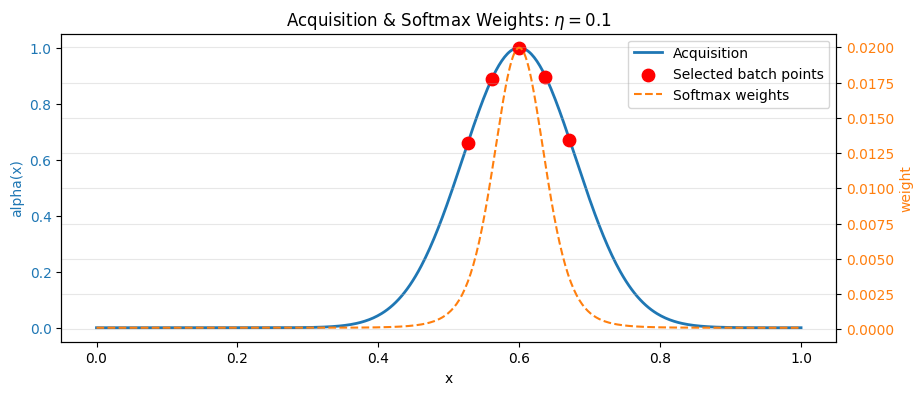

In [3]:

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 1.0]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l=0.1,
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 0.1$")
plt.grid(alpha=0.3)
plt.show()

## toy acquisition function: $e^{-0.5\frac{(x/10-0.6)^2}{0.08^2}}$

In [4]:
def toy_acquisition(X):
    """
    X: (N, 1)
    return: (N,)
    """
    mu = 0.6
    sigma = 0.08
    return torch.exp(-0.5 * ((X.squeeze()/10 - mu) / sigma) ** 2)

/data1/qcq4123155034/CBBO
---------X: tensor([[ 0.0000],
        [ 0.0200],
        [ 0.0401],
        [ 0.0601],
        [ 0.0802],
        [ 0.1002],
        [ 0.1202],
        [ 0.1403],
        [ 0.1603],
        [ 0.1804],
        [ 0.2004],
        [ 0.2204],
        [ 0.2405],
        [ 0.2605],
        [ 0.2806],
        [ 0.3006],
        [ 0.3206],
        [ 0.3407],
        [ 0.3607],
        [ 0.3808],
        [ 0.4008],
        [ 0.4208],
        [ 0.4409],
        [ 0.4609],
        [ 0.4810],
        [ 0.5010],
        [ 0.5210],
        [ 0.5411],
        [ 0.5611],
        [ 0.5812],
        [ 0.6012],
        [ 0.6212],
        [ 0.6413],
        [ 0.6613],
        [ 0.6814],
        [ 0.7014],
        [ 0.7214],
        [ 0.7415],
        [ 0.7615],
        [ 0.7816],
        [ 0.8016],
        [ 0.8216],
        [ 0.8417],
        [ 0.8617],
        [ 0.8818],
        [ 0.9018],
        [ 0.9218],
        [ 0.9419],
        [ 0.9619],
        [ 0.9820],
        [ 1.

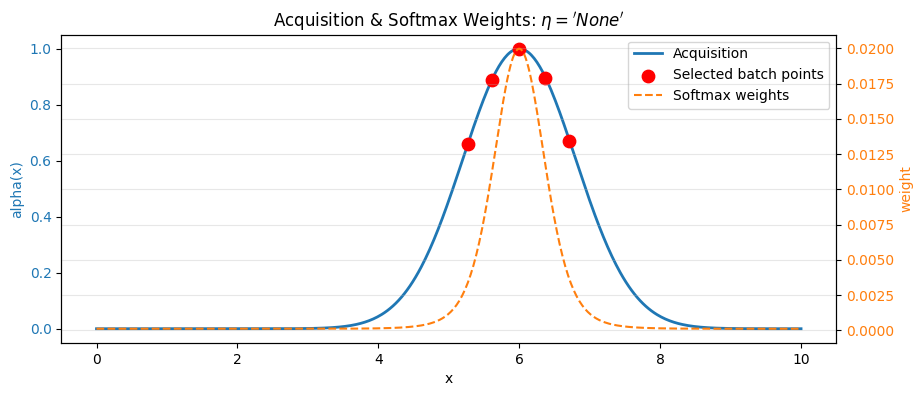

In [5]:


notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 10]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l='None',
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 'None'$")
plt.grid(alpha=0.3)
plt.show()

/data1/qcq4123155034/CBBO
---------X: tensor([[ 0.0000],
        [ 0.0200],
        [ 0.0401],
        [ 0.0601],
        [ 0.0802],
        [ 0.1002],
        [ 0.1202],
        [ 0.1403],
        [ 0.1603],
        [ 0.1804],
        [ 0.2004],
        [ 0.2204],
        [ 0.2405],
        [ 0.2605],
        [ 0.2806],
        [ 0.3006],
        [ 0.3206],
        [ 0.3407],
        [ 0.3607],
        [ 0.3808],
        [ 0.4008],
        [ 0.4208],
        [ 0.4409],
        [ 0.4609],
        [ 0.4810],
        [ 0.5010],
        [ 0.5210],
        [ 0.5411],
        [ 0.5611],
        [ 0.5812],
        [ 0.6012],
        [ 0.6212],
        [ 0.6413],
        [ 0.6613],
        [ 0.6814],
        [ 0.7014],
        [ 0.7214],
        [ 0.7415],
        [ 0.7615],
        [ 0.7816],
        [ 0.8016],
        [ 0.8216],
        [ 0.8417],
        [ 0.8617],
        [ 0.8818],
        [ 0.9018],
        [ 0.9218],
        [ 0.9419],
        [ 0.9619],
        [ 0.9820],
        [ 1.

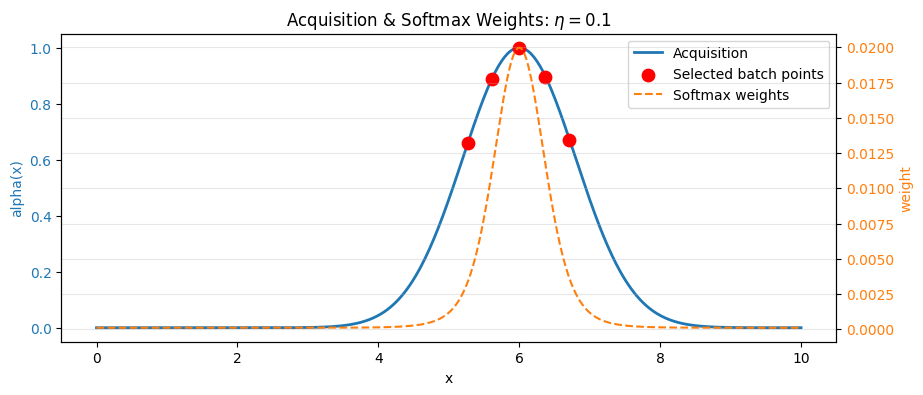

In [6]:


notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 10]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l=0.1,
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 0.1$")
plt.grid(alpha=0.3)
plt.show()

## toy acquisition function: $e^{-0.5\frac{(x/100-0.6)^2}{0.08^2}}$

In [7]:
def toy_acquisition(X):
    """
    X: (N, 1)
    return: (N,)
    """
    mu = 0.6
    sigma = 0.08
    return torch.exp(-0.5 * ((X.squeeze()/100 - mu) / sigma) ** 2)

/data1/qcq4123155034/CBBO
---------X: tensor([[  0.0000],
        [  0.2004],
        [  0.4008],
        [  0.6012],
        [  0.8016],
        [  1.0020],
        [  1.2024],
        [  1.4028],
        [  1.6032],
        [  1.8036],
        [  2.0040],
        [  2.2044],
        [  2.4048],
        [  2.6052],
        [  2.8056],
        [  3.0060],
        [  3.2064],
        [  3.4068],
        [  3.6072],
        [  3.8076],
        [  4.0080],
        [  4.2084],
        [  4.4088],
        [  4.6092],
        [  4.8096],
        [  5.0100],
        [  5.2104],
        [  5.4108],
        [  5.6112],
        [  5.8116],
        [  6.0120],
        [  6.2124],
        [  6.4128],
        [  6.6132],
        [  6.8136],
        [  7.0140],
        [  7.2144],
        [  7.4148],
        [  7.6152],
        [  7.8156],
        [  8.0160],
        [  8.2164],
        [  8.4168],
        [  8.6172],
        [  8.8176],
        [  9.0180],
        [  9.2184],
        [  9.4188],
  

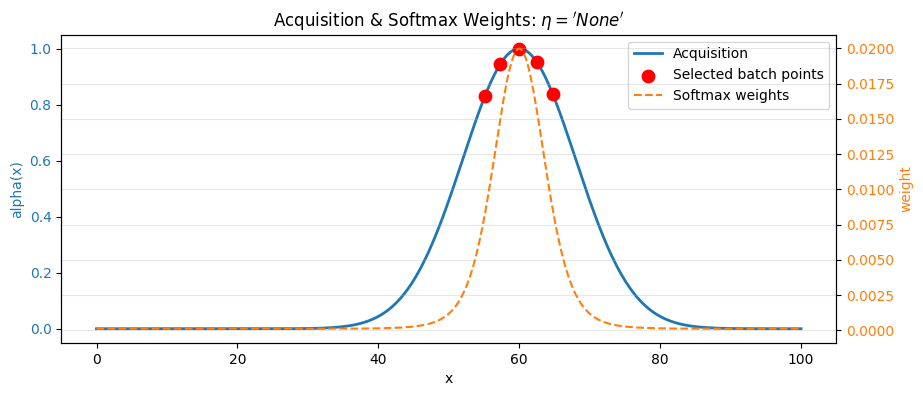

In [8]:

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 100]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l='None',
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 'None'$")
plt.grid(alpha=0.3)
plt.show()

/data1/qcq4123155034/CBBO
---------X: tensor([[  0.0000],
        [  0.2004],
        [  0.4008],
        [  0.6012],
        [  0.8016],
        [  1.0020],
        [  1.2024],
        [  1.4028],
        [  1.6032],
        [  1.8036],
        [  2.0040],
        [  2.2044],
        [  2.4048],
        [  2.6052],
        [  2.8056],
        [  3.0060],
        [  3.2064],
        [  3.4068],
        [  3.6072],
        [  3.8076],
        [  4.0080],
        [  4.2084],
        [  4.4088],
        [  4.6092],
        [  4.8096],
        [  5.0100],
        [  5.2104],
        [  5.4108],
        [  5.6112],
        [  5.8116],
        [  6.0120],
        [  6.2124],
        [  6.4128],
        [  6.6132],
        [  6.8136],
        [  7.0140],
        [  7.2144],
        [  7.4148],
        [  7.6152],
        [  7.8156],
        [  8.0160],
        [  8.2164],
        [  8.4168],
        [  8.6172],
        [  8.8176],
        [  9.0180],
        [  9.2184],
        [  9.4188],
  

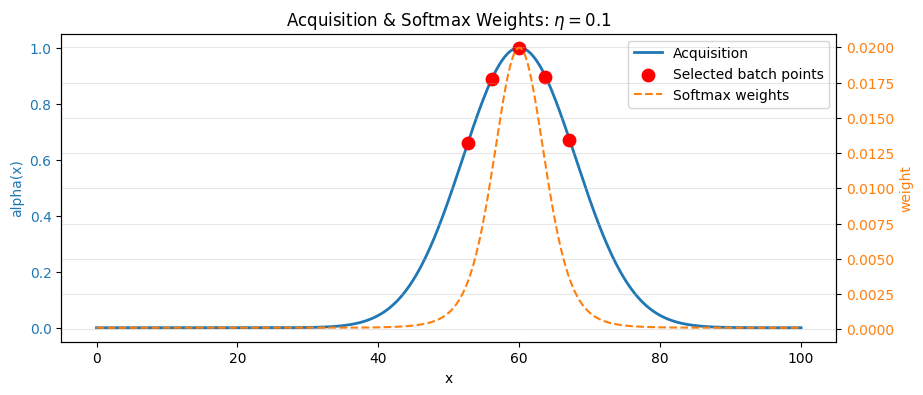

In [9]:


notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 100]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l=0.1,
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 0.1$")
plt.grid(alpha=0.3)
plt.show()

## toy acquisition function: $e^{-0.5\frac{(x/1000-0.6)^2}{0.08^2}}$

In [10]:
def toy_acquisition(X):
    """
    X: (N, 1)
    return: (N,)
    """
    mu = 0.6
    sigma = 0.08
    return torch.exp(-0.5 * ((X.squeeze()/1000 - mu) / sigma) ** 2)

/data1/qcq4123155034/CBBO
---------X: tensor([[   0.0000],
        [   2.0040],
        [   4.0080],
        [   6.0120],
        [   8.0160],
        [  10.0200],
        [  12.0240],
        [  14.0281],
        [  16.0321],
        [  18.0361],
        [  20.0401],
        [  22.0441],
        [  24.0481],
        [  26.0521],
        [  28.0561],
        [  30.0601],
        [  32.0641],
        [  34.0681],
        [  36.0721],
        [  38.0762],
        [  40.0802],
        [  42.0842],
        [  44.0882],
        [  46.0922],
        [  48.0962],
        [  50.1002],
        [  52.1042],
        [  54.1082],
        [  56.1122],
        [  58.1162],
        [  60.1202],
        [  62.1242],
        [  64.1283],
        [  66.1323],
        [  68.1363],
        [  70.1403],
        [  72.1443],
        [  74.1483],
        [  76.1523],
        [  78.1563],
        [  80.1603],
        [  82.1643],
        [  84.1683],
        [  86.1723],
        [  88.1764],
        [  90.180

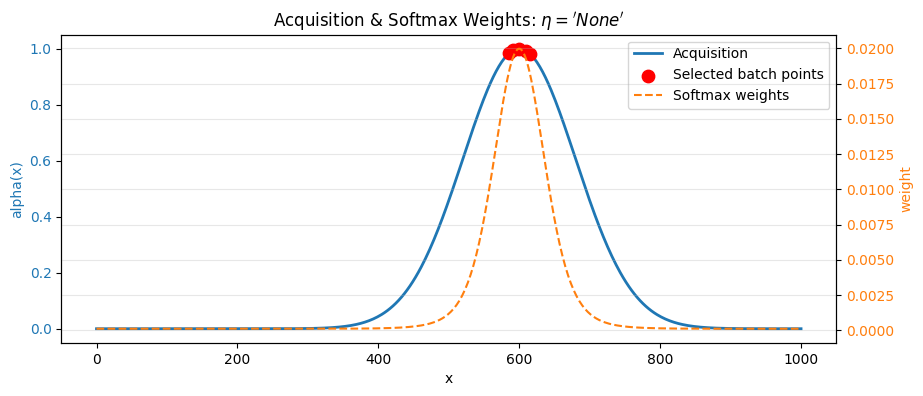

In [11]:

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 1000]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l='None',
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 'None'$")
plt.grid(alpha=0.3)
plt.show()

/data1/qcq4123155034/CBBO
---------X: tensor([[   0.0000],
        [   2.0040],
        [   4.0080],
        [   6.0120],
        [   8.0160],
        [  10.0200],
        [  12.0240],
        [  14.0281],
        [  16.0321],
        [  18.0361],
        [  20.0401],
        [  22.0441],
        [  24.0481],
        [  26.0521],
        [  28.0561],
        [  30.0601],
        [  32.0641],
        [  34.0681],
        [  36.0721],
        [  38.0762],
        [  40.0802],
        [  42.0842],
        [  44.0882],
        [  46.0922],
        [  48.0962],
        [  50.1002],
        [  52.1042],
        [  54.1082],
        [  56.1122],
        [  58.1162],
        [  60.1202],
        [  62.1242],
        [  64.1283],
        [  66.1323],
        [  68.1363],
        [  70.1403],
        [  72.1443],
        [  74.1483],
        [  76.1523],
        [  78.1563],
        [  80.1603],
        [  82.1643],
        [  84.1683],
        [  86.1723],
        [  88.1764],
        [  90.180

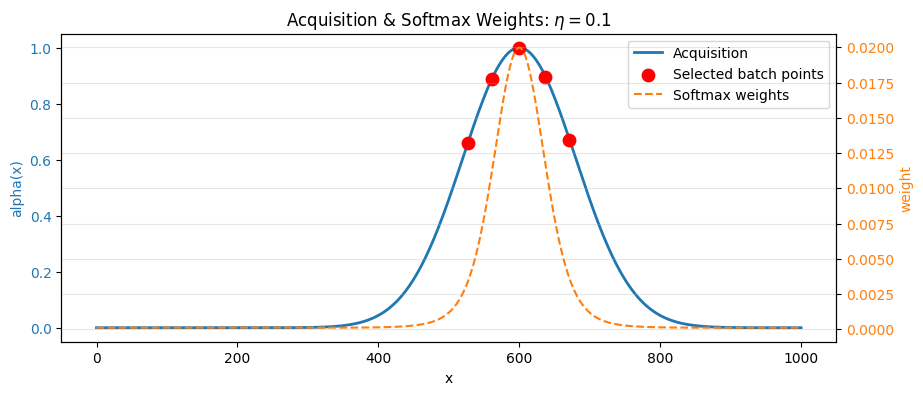

In [13]:

notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step

bounds = [[0.0, 1000]]
q = 5
batch_points, X, w= coverage_batch_bo_step(
    acquisition_function=toy_acquisition,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=500,
    eta_l=0.1,
    eta_tau=0.6,
)

fig, ax1 = plt.subplots(figsize=(10, 4))

# left axix：acquisition
ax1.plot(X, toy_acquisition(X), label="Acquisition", linewidth=2, color='C0')
ax1.scatter(batch_points,
            toy_acquisition(batch_points),
            color="red",
            s=80,
            zorder=5,
            label="Selected batch points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X, w, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights: $\eta = 0.1 $")
plt.grid(alpha=0.3)
plt.show()